Device set to use cuda:0
Translating: 100%|██████████████████████████████████████████████████████████████████████████████| 47/47 [02:20<00:00,  2.99s/it]


Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

[OPTIMIZER] epoch_start=0 global_step=0 wrapped=AcceleratedOptimizer base=AdamW lr=0.0 id=132505847503648 hyperparams={'lr': 0.0, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[OPTIMIZER_GROUP]   group[0] {'lr': 0.0, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[SCHEDULER]   scheduler_last_lr=[0.0]
[PARAMS]   params_total=129,137,667 params_trainable=129,137,667


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro,Mse,Sse
1,2.555300,0.911917,0.583333,0.583593,0.585931,0.583333,0.182476,54.742771
2,1.606900,0.717504,0.736667,0.737977,0.740765,0.736667,0.137862,41.358488
3,1.310800,0.589938,0.773333,0.773854,0.774548,0.773333,0.111308,33.392525
4,1.016500,0.516822,0.800000,0.799620,0.799345,0.800000,0.097431,29.229368
5,0.914000,0.479985,0.806667,0.806392,0.806199,0.806667,0.090858,27.257289
6,0.768400,0.459993,0.806667,0.806613,0.806753,0.806667,0.087451,26.235280
7,0.714500,0.454170,0.813333,0.813507,0.814206,0.813333,0.086588,25.976503


[TRAINING_PERFORMANCE] epoch=1.0 tokens=0 time=29.16s tok/s=0.0 ex/s=0.00 peak_mem=2.56GiB lr=9.13e-06
[EVALUATION_PERFORMANCE] tokens=81920 time=0.55s tok/s=149612.1 ex/s=1168.84
[EVALUATION_PERFORMANCE] accuracy=0.5833 cost=$0.02 accuracy_per_$=34.24
[OPTIMIZER] epoch_start=1.0 global_step=75 wrapped=AcceleratedOptimizer base=AdamW lr=9.127789046653144e-06 id=132505847503648 hyperparams={'lr': 9.127789046653144e-06, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[OPTIMIZER_GROUP]   group[0] {'lr': 9.127789046653144e-06, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[SCHEDULER]   scheduler_last_lr=[9.127789046653144e-06]
[PARAMS]   pa

[EVALUATION_PERFORMANCE] tokens=81920 time=0.56s tok/s=145167.4 ex/s=1134.12
[EVALUATION_PERFORMANCE] accuracy=0.8233 cost=$0.18 accuracy_per_$=4.65

### STATE-SPACES/MAMBA-130M-HF EVALUATION METRICS ###
{'epoch': 7.0,
 'eval_accuracy': 0.8233333333333334,
 'eval_f1_macro': 0.8223419579988199,
 'eval_loss': 0.5103223919868469,
 'eval_mse': 0.09361771419115034,
 'eval_precision_macro': 0.8232256717688274,
 'eval_recall_macro': 0.8233333333333334,
 'eval_runtime': 0.6302,
 'eval_samples_per_second': 476.059,
 'eval_sse': 28.0853142573451,
 'eval_steps_per_second': 7.934}


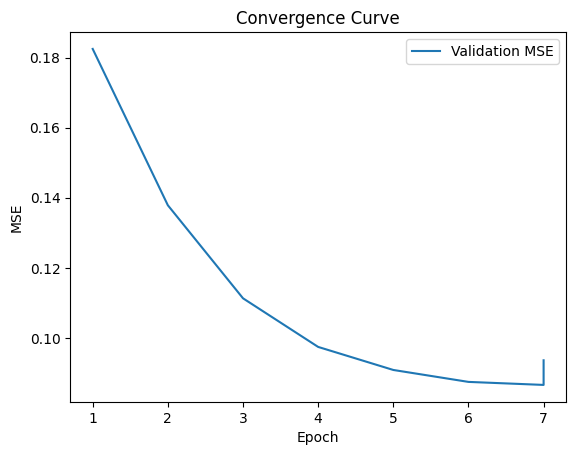

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2400 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

In [1]:
# A State Space Model Approach to Cross-Lingual Sentiment Analysis of Filipino Texts 


import os
import pandas as pd
import pprint

from pathlib import Path
from transformers import pipeline

from src.config import *
from src.metrics import evaluate_pipe
from src import (
    context,
    helper,
    sentiment, 
    utility, 
)

os.environ["HF_DATASETS_DISABLE_CACHING"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
helper.list_config()

if App.HAS_GPU:
    os.environ["MAMBA_USE_MAMBAPY"] = Mamba.FORCE_CUDA
    os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

if App.ACTION == "TRAIN":
    mamba_context = context.setup_pipeline(Mamba, require_translation = True)
    mamba_trainer = sentiment.train(mamba_context)

